In [1]:
import psutil
import platform
import os
env_name = os.environ.get('CONDA_DEFAULT_ENV')
print("当前 conda 环境名：", env_name)
print(platform.system()) # 操作系统名称
print(platform.release()) # 操作系统版本
print(platform.machine()) # 计算机架构
print(platform.processor()) # 处理器类型
# CPU 信息
print(psutil.cpu_count()) # CPU 核数
print(psutil.cpu_freq()) # CPU 频率
# 内存信息
print(psutil.virtual_memory()) # 内存总量、可用内存、已用内存等

当前 conda 环境名： gxy
Windows
10
AMD64
Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
20
scpufreq(current=2400.0, min=0.0, max=2400.0)
svmem(total=16961822720, available=6536851456, percent=61.5, used=10424971264, free=6536851456)


# 2 概述、线性代数和 NDArray

## 2.1 理论计算题

已知：  
a = [2, -1, 3]  
b = [1, 4, -2]  

A = [ [1, 0, 2],  
      [-1, 3, 1] ]   （2行3列）

B = [ [2, 1],  
      [0, -1],  
      [3, 2] ]       （3行2列）

---

### 1. 点积 a·b  
2×1 + (-1)×4 + 3×(-2) = 2 - 4 - 6 = **-8**

### 2. 矩阵乘法 A×B  
结果形状：2行2列  

第一行第一列：1×2 + 0×0 + 2×3 = 2+0+6 = 8  
第一行第二列：1×1 + 0×(-1) + 2×2 = 1+0+4 = 5  
第二行第一列：(-1)×2 + 3×0 + 1×3 = -2+0+3 = 1  
第二行第二列：(-1)×1 + 3×(-1) + 1×2 = -1-3+2 = -2  

所以 A×B = [ [8, 5],  
             [1, -2] ]

### 3. a 的 Frobenius 范数  
√(2² + (-1)² + 3²) = √(4+1+9) = **√14**

In [2]:
import numpy as np

# 设定随机种子，确保输出可复现
np.random.seed(42)

# 1. 创建 3×4 随机矩阵 X，元素服从标准正态分布
X = np.random.randn(3, 4)
print("X =\n", X, "\n")

# 2. 创建 4×2 全 1 矩阵 Y
Y = np.ones((4, 2))
print("Y =\n", Y, "\n")

# 3. 矩阵乘法 Z = X × Y
Z = X @ Y   # 或 np.matmul(X, Y)
print("Z = X × Y =\n", Z, "\n")

# 4. 输出指定元素
# Z 的第一行和第二列交叉处的元素：索引 (0,1)
elem_0_1 = Z[0, 1]
print("Z 的第一行第二列元素:", elem_0_1)

# Z 的第二行所有元素：索引 1 整行
row_1 = Z[1, :]
print("Z 的第二行所有元素:", row_1, "\n")

# 5. 计算 Z 的 Frobenius 范数 (L2 范数)
frob_norm = np.linalg.norm(Z)
print("Z 的 Frobenius 范数:", frob_norm)

X =
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]] 

Y =
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]] 

Z = X × Y =
 [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]] 

Z 的第一行第二列元素: 2.5291682463487657
Z 的第二行所有元素: [1.87835721 1.87835721] 

Z 的 Frobenius 范数: 4.616873319476864


## 3.1 理论计算题

已知：  
- 患病率 = 0.1% = 0.001  
- 患病时阳性的概率 = 99% = 0.99  
- 未患病时阳性的概率 = 2% = 0.02  

**步骤1：计算总体阳性概率** 
P(阳性) = P(阳性|患病)P(患病) + P(阳性|未患病)P(未患病) = 0.99*0.001 + 0.02*(1-0.001) = 0.00099 + 0.02*0.999 = 0.00099 + 0.01998 = 0.02097

**步骤2：计算患病概率** 
P(患病|阳性) = (0.99*0.001) / 0.02097 = 0.00099 / 0.02097 ≈ 0.04721 = 4.721%

因此，该检测结果为阳性的人真正患病的概率约为 4.72%

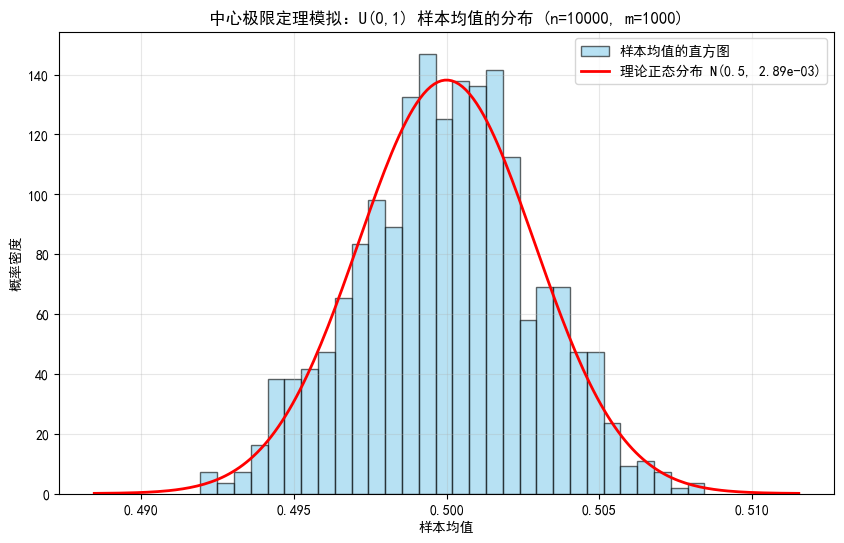

样本均值的实际方差: 8.27563701e-06
理论方差 (σ²/n): 8.33333333e-06
理论标准差 (σ/√n): 0.002887


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ========== 设置中文字体（解决警告）==========
plt.rcParams['font.sans-serif'] = ['SimHei']        # 使用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False          # 解决负号显示为方块的问题

# ========== 参数设置 ==========
n = 10000      # 每次抽取的样本量
m = 1000       # 重复次数

# ========== 1. 生成样本均值 ==========
np.random.seed(42)  # 固定随机种子，保证结果可复现
sample_means = np.zeros(m)
for i in range(m):
    sample = np.random.uniform(0, 1, n)   # 生成 n 个 U(0,1) 随机数
    sample_means[i] = np.mean(sample)      # 计算均值并存储

# ========== 2. 绘制直方图与理论正态分布曲线 ==========
plt.figure(figsize=(10, 6))
# 直方图（密度归一化）
count, bins, ignored = plt.hist(sample_means, bins=30, density=True, 
                                alpha=0.6, color='skyblue', edgecolor='black', 
                                label='样本均值的直方图')

# 理论正态分布：总体均值 μ=0.5，方差 σ² = (1/12)/n
mu_theory = 0.5
sigma_theory = np.sqrt((1/12) / n)          # 理论标准差
x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 200)
pdf_theory = norm.pdf(x, mu_theory, sigma_theory)
plt.plot(x, pdf_theory, 'r-', linewidth=2, 
         label=f'理论正态分布 N({mu_theory}, {sigma_theory:.2e})')

# 图表修饰
plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('中心极限定理模拟：U(0,1) 样本均值的分布 (n=10000, m=1000)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ========== 3. 计算实际方差并与理论值对比 ==========
actual_var = np.var(sample_means, ddof=0)   # 总体方差（除以 m）
print(f"样本均值的实际方差: {actual_var:.8e}")
print(f"理论方差 (σ²/n): {(1/12)/n:.8e}")
print(f"理论标准差 (σ/√n): {sigma_theory:.6f}")

## 4.1 理论计算题

函数：`z = (2·w1 + 1·w2 - 3)²`

**1. 偏导表达式**  
∂z/∂w1 = 4·(2·w1 + w2 - 3)  
∂z/∂w2 = 2·(2·w1 + w2 - 3)

**2. 当 w1=0.5, w2=1 时**  
先算括号：2×0.5 + 1 - 3 = -1  
∂z/∂w1 = 4×(-1) = **-4**  
∂z/∂w2 = 2×(-1) = **-2**  
梯度 = [-4, -2]

In [4]:
import torch

# ========== 手动实现计算图（前向 + 反向）==========
x = 2.0
w1 = 1.5
w2 = 0.5

# 前向计算
a = x * w1
b = a + w2
L = b ** 2   # L = b^2

print("【手动前向】")
print(f"a = x * w1 = {a}")
print(f"b = a + w2 = {b}")
print(f"L = b^2 = {L}\n")

# 手动反向传播（链式法则）
dL_dL = 1.0
dL_db = 2 * b                     # dL/db = 2b
db_da = 1.0
db_dw2 = 1.0
da_dw1 = x

dL_dw1 = dL_db * db_da * da_dw1   # 7 * 1 * 2 = 14
dL_dw2 = dL_db * db_dw2           # 7 * 1 = 7

print("【手动梯度】")
print(f"∂L/∂w1 = {dL_dw1}")
print(f"∂L/∂w2 = {dL_dw2}\n")

# ========== 用 PyTorch 自动微分验证 ==========
x_t = torch.tensor(2.0, requires_grad=False)
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

L_t.backward()

print("【PyTorch 自动微分】")
print(f"∂L/∂w1 = {w1_t.grad.item()}")
print(f"∂L/∂w2 = {w2_t.grad.item()}\n")

# 验证一致性
if w1_t.grad.item() == dL_dw1 and w2_t.grad.item() == dL_dw2:
    print("✅ 手动梯度与自动微分结果完全一致！")
else:
    print("❌ 不一致，请检查计算。")

【手动前向】
a = x * w1 = 3.0
b = a + w2 = 3.5
L = b^2 = 12.25

【手动梯度】
∂L/∂w1 = 14.0
∂L/∂w2 = 7.0

【PyTorch 自动微分】
∂L/∂w1 = 14.0
∂L/∂w2 = 7.0

✅ 手动梯度与自动微分结果完全一致！


## 5.1 理论计算题

模型：ŷ = wx + b  
损失：L = (1/n) Σ (y - ŷ)²

**偏导结果：**

∂L/∂w = - (2/n) Σ x·(y - wx - b)  
∂L/∂b = - (2/n) Σ (y - wx - b)

其中 Σ 表示对 i=1 到 n 求和。

开始训练 Softmax 回归...
Epoch  10/50 | Loss: 0.127845 | Train Acc: 0.9819
Epoch  20/50 | Loss: 0.085690 | Train Acc: 0.9896
Epoch  30/50 | Loss: 0.067545 | Train Acc: 0.9910
Epoch  40/50 | Loss: 0.056725 | Train Acc: 0.9910
Epoch  50/50 | Loss: 0.049451 | Train Acc: 0.9930

最终测试集准确率: 0.9750 (97.50%)


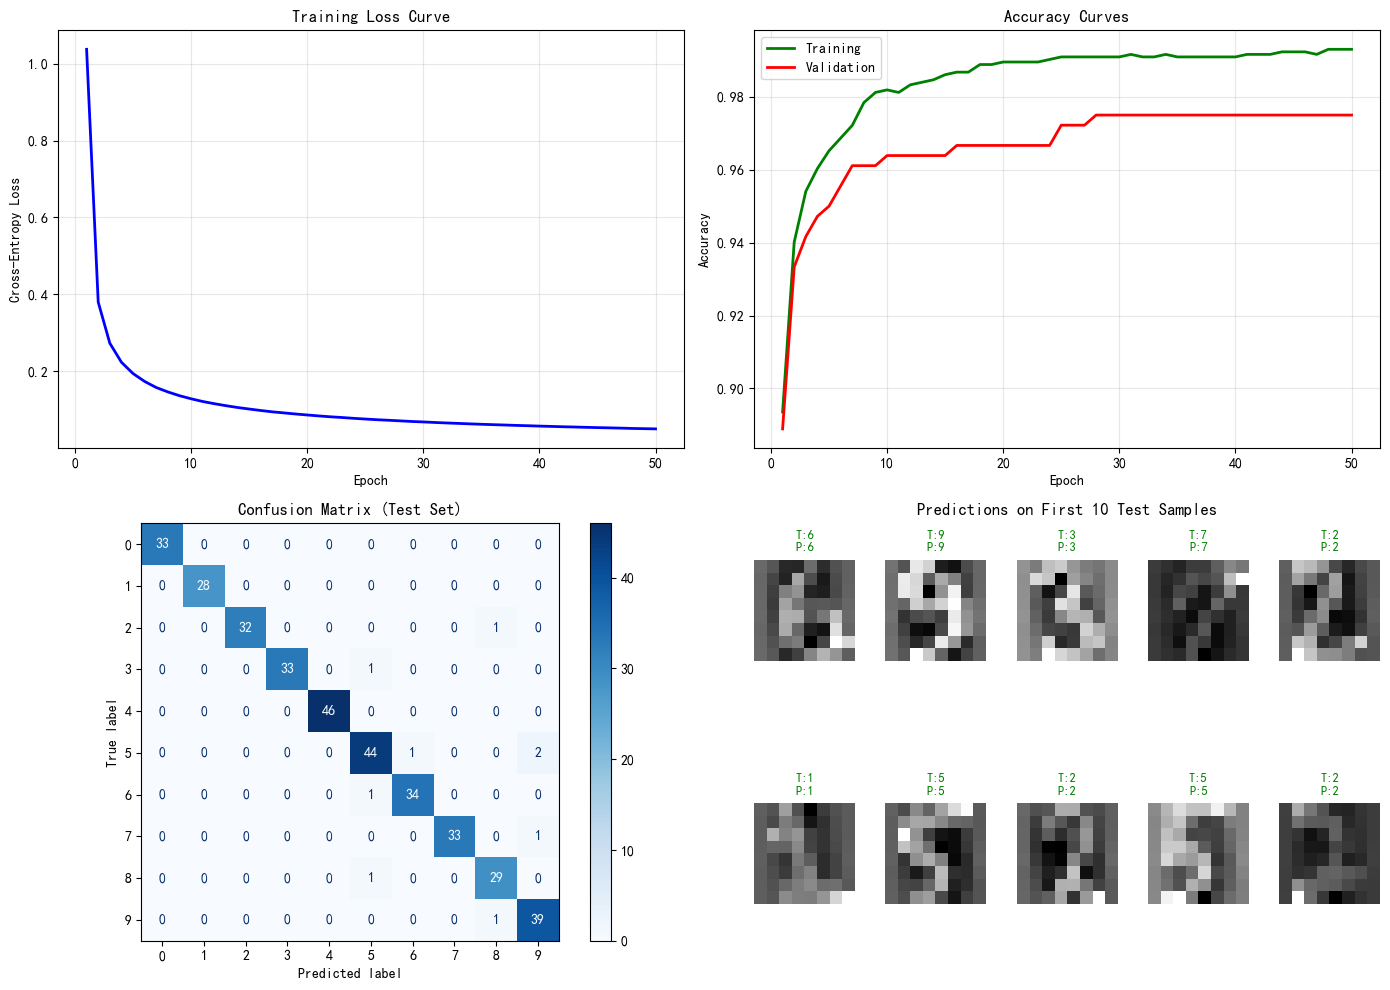

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# 1. 加载数据与预处理
# -----------------------------
digits = load_digits()
X, y = digits.data, digits.target
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n_features = X_train.shape[1]
n_classes = 10

# -----------------------------
# 2. One-hot 编码
# -----------------------------
def one_hot_encoding(y, K):
    return np.eye(K)[y]

y_train_onehot = one_hot_encoding(y_train, n_classes)
y_test_onehot = one_hot_encoding(y_test, n_classes)

# -----------------------------
# 3. 核心函数
# -----------------------------
def softmax(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def cross_entropy_loss(probs, y_onehot):
    return -np.mean(np.sum(y_onehot * np.log(probs + 1e-8), axis=1))

# -----------------------------
# 4. 小批量 SGD 训练类
# -----------------------------
class SoftmaxReg:
    def __init__(self, lr=0.1, batch_size=32, epochs=50):
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.W = None
        self.b = None

    def init_params(self, in_dim, out_dim):
        self.W = np.random.randn(in_dim, out_dim) * np.sqrt(2.0 / in_dim)
        self.b = np.zeros(out_dim)

    def forward(self, X):
        return softmax(X @ self.W + self.b)

    def compute_gradients(self, X_batch, y_batch_onehot):
        probs = self.forward(X_batch)
        n = X_batch.shape[0]
        grad_W = (X_batch.T @ (probs - y_batch_onehot)) / n
        grad_b = np.mean(probs - y_batch_onehot, axis=0)
        return grad_W, grad_b

    def fit(self, X, y_onehot, X_val=None, y_val=None):
        m = X.shape[0]
        self.init_params(X.shape[1], y_onehot.shape[1])

        self.train_losses = []
        self.train_accs = []
        self.val_accs = []

        for epoch in range(1, self.epochs + 1):
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y_onehot[indices]

            epoch_loss = 0.0
            for i in range(0, m, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                grad_W, grad_b = self.compute_gradients(X_batch, y_batch)
                self.W -= self.lr * grad_W
                self.b -= self.lr * grad_b
                loss = cross_entropy_loss(self.forward(X_batch), y_batch)
                epoch_loss += loss * len(X_batch)

            avg_loss = epoch_loss / m
            self.train_losses.append(avg_loss)

            train_pred = np.argmax(self.forward(X), axis=1)
            self.train_accs.append(np.mean(train_pred == np.argmax(y_onehot, axis=1)))

            if X_val is not None:
                val_pred = np.argmax(self.forward(X_val), axis=1)
                self.val_accs.append(np.mean(val_pred == y_val))

            if epoch % 10 == 0:
                print(f"Epoch {epoch:3d}/{self.epochs} | Loss: {avg_loss:.6f} | Train Acc: {self.train_accs[-1]:.4f}")

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

# -----------------------------
# 5. 训练模型
# -----------------------------
model = SoftmaxReg(lr=0.1, batch_size=32, epochs=50)
print("开始训练 Softmax 回归...")
model.fit(X_train, y_train_onehot, X_test, y_test)

test_acc = model.score(X_test, y_test)
print(f"\n最终测试集准确率: {test_acc:.4f} ({test_acc*100:.2f}%)")

# -----------------------------
# 6. 绘图（修复 tight_layout 错误）
# -----------------------------
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# 创建 2x2 的子图布局，其中右下角的子图再划分为 2x5 小图
fig = plt.figure(figsize=(14, 10))

# 损失曲线
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(range(1, model.epochs+1), model.train_losses, 'b-', lw=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training Loss Curve')
ax1.grid(alpha=0.3)

# 准确率曲线
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(range(1, model.epochs+1), model.train_accs, 'g-', lw=2, label='Training')
ax2.plot(range(1, model.epochs+1), model.val_accs, 'r-', lw=2, label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(alpha=0.3)

# 混淆矩阵
ax3 = fig.add_subplot(2, 2, 3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
disp.plot(ax=ax3, cmap='Blues', values_format='d')
ax3.set_title('Confusion Matrix (Test Set)')

# 预测示例：在右下角单独创建一个 2x5 的网格，不嵌套子图
ax4 = fig.add_subplot(2, 2, 4)
ax4.axis('off')  # 隐藏大轴的边框
# 在这个大轴内部手动放置小图（使用 add_axes 或 inset_axes 会更安全，但用 subplot 嵌套也可）
# 为避免 tight_layout 冲突，这里改用 gridspec 或直接设置位置
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpecFromSubplotSpec(2, 5, subplot_spec=ax4.get_subplotspec(), wspace=0.3, hspace=0.4)
for i in range(10):
    row, col = i // 5, i % 5
    ax = fig.add_subplot(gs[row, col])
    ax.imshow(X_test[i].reshape(8, 8), cmap='gray')
    true, pred = y_test[i], y_pred[i]
    color = 'green' if true == pred else 'red'
    ax.set_title(f'T:{true}\nP:{pred}', fontsize=9, color=color)
    ax.axis('off')
ax4.set_title('Predictions on First 10 Test Samples', fontsize=12)

plt.tight_layout()
plt.show()

6.1 理论计算题

样本 x1, x2, ..., xn 独立同分布，服从正态分布 N(μ, σ²)。

1. 似然函数 L(μ, σ²)：
   所有样本的概率密度乘起来：
   L = (2πσ²)^(-n/2) * exp( - [ (x1-μ)² + (x2-μ)² + ... + (xn-μ)² ] / (2σ²) )

2. μ 的最大似然估计：
   对 L 取对数，再对 μ 求导，令导数为 0，得到：
   (x1-μ)+(x2-μ)+...+(xn-μ) = 0
   解得 μ̂ = (x1+x2+...+xn) / n   （即样本平均值）

3. σ² 的最大似然估计：
   将 μ 替换为 μ̂，再对 σ² 求导，令导数为 0，得到：
   σ̂² = [ (x1-μ̂)² + (x2-μ̂)² + ... + (xn-μ̂)² ] / n = (1/n) ∑(x_i - μ̂)²
   （即样本的“平均平方偏差”，分母是 n，不是 n-1）

Iter  200, Loss = 0.319005
Iter  400, Loss = 0.235081
Iter  600, Loss = 0.197302
Iter  800, Loss = 0.175838
Iter 1000, Loss = 0.161983


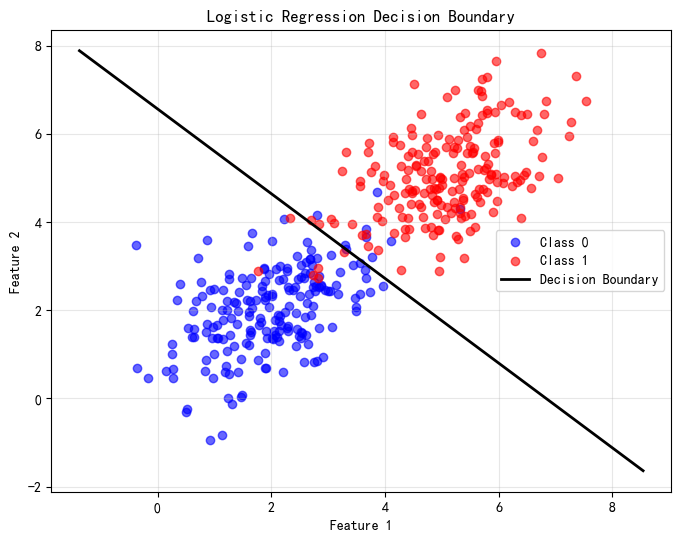


测试集准确率: 1.0000 (100.00%)


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(42)

# -----------------------------
# 1. 生成两类线性可分数据（训练集：每类200个）
# -----------------------------
# 类别0：均值 (2,2)，协方差 [[1,0.5],[0.5,1]]
mean0 = [2, 2]
cov0 = [[1, 0.5], [0.5, 1]]
X0 = np.random.multivariate_normal(mean0, cov0, 200)
y0 = np.zeros(200)   # 标签0

# 类别1：均值 (5,5)，协方差 [[1,0.5],[0.5,1]]
mean1 = [5, 5]
cov1 = [[1, 0.5], [0.5, 1]]
X1 = np.random.multivariate_normal(mean1, cov1, 200)
y1 = np.ones(200)    # 标签1

# 合并训练集
X_train = np.vstack((X0, X1))
y_train = np.hstack((y0, y1))

# 添加一列偏置项（或者单独用b），这里采用单独b参数
# -----------------------------
# 2. 定义 sigmoid 函数和二元交叉熵损失（及梯度）
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y, y_pred):
    # 二元交叉熵损失，加小量防止 log(0)
    return -np.mean(y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8))

def compute_gradients(X, y, w, b):
    # 前向
    z = X @ w + b
    y_pred = sigmoid(z)
    # 梯度
    dw = (1/len(y)) * (X.T @ (y_pred - y))
    db = (1/len(y)) * np.sum(y_pred - y)
    return dw, db

# -----------------------------
# 3. 梯度下降训练参数 w, b
# -----------------------------
def train(X, y, lr=0.1, iterations=1000):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)   # 权重初始化
    b = 0.0
    losses = []
    for i in range(iterations):
        z = X @ w + b
        y_pred = sigmoid(z)
        loss = compute_loss(y, y_pred)
        losses.append(loss)
        dw, db = compute_gradients(X, y, w, b)
        w -= lr * dw
        b -= lr * db
        if (i+1) % 200 == 0:
            print(f"Iter {i+1:4d}, Loss = {loss:.6f}")
    return w, b, losses

# 训练
w, b, losses = train(X_train, y_train, lr=0.1, iterations=1000)

# -----------------------------
# 4. 绘制决策边界
# -----------------------------
def plot_decision_boundary(X, y, w, b):
    plt.figure(figsize=(8, 6))
    # 散点图
    plt.scatter(X[y==0][:,0], X[y==0][:,1], c='blue', label='Class 0', alpha=0.6)
    plt.scatter(X[y==1][:,0], X[y==1][:,1], c='red', label='Class 1', alpha=0.6)
    # 决策边界： w0*x + w1*y + b = 0 => x2 = -(w0*x1 + b)/w1
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx = np.linspace(x_min, x_max, 200)
    yy = -(w[0]*xx + b) / w[1]
    plt.plot(xx, yy, 'k-', linewidth=2, label='Decision Boundary')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Logistic Regression Decision Boundary')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_decision_boundary(X_train, y_train, w, b)

# -----------------------------
# 5. 生成测试集（新生成100个样本，每类50个）
# -----------------------------
X0_test = np.random.multivariate_normal(mean0, cov0, 50)
X1_test = np.random.multivariate_normal(mean1, cov1, 50)
X_test = np.vstack((X0_test, X1_test))
y_test = np.hstack((np.zeros(50), np.ones(50)))

# 预测
def predict(X, w, b):
    prob = sigmoid(X @ w + b)
    return (prob >= 0.5).astype(int)

y_pred = predict(X_test, w, b)
accuracy = np.mean(y_pred == y_test)
print(f"\n测试集准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")